In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# path = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/Known_Trans/intra1/experiment_results/experiment_robustness.json"
# path = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/Known_Trans/intra1/experiment_results/experiment_full_sweep.json"
# path = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/Known_Trans/intra1/experiment_results/experiment_missing_data_constraints.json"
# path = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/Known_Trans/intra1/experiment_results/experiment_missing_data.json"
path = "/Users/elise/elisedonszelmann-lund/Masters_Utils/Pig_Data/pig2/Registration/experiments/sofa3/slice/robust_constraints_8_8.json"

with open(path, "r") as f:
    data = json.load(f)

tables = {}

for exp_name, exp_data in data.items():
    if exp_name == "_summary":
        continue

    rows = []
    for i in range(len(exp_data["runtime_sec"])):
        row = {
            "run": i,
            "runtime_sec": exp_data["runtime_sec"][i],
            "success": exp_data["success"][i],
        }

        for v in ["L1", "L2", "L3", "L4"]:
            row[f"init_{v}"]  = exp_data["initial_tre"][i][v]
            row[f"final_{v}"] = exp_data["final_tre"][i][v]

        rows.append(row)

    tables[exp_name] = pd.DataFrame(rows)

# collect all final TRE values across all experiments
all_final_vals = []

for df in tables.values():
    for v in ["L1", "L2", "L3", "L4"]:
        all_final_vals.extend(df[f"final_{v}"].dropna().values)

ymax = np.max(all_final_vals)
ymax = np.ceil(ymax * 2) / 2   # round up to nearest 0.5 mm

## PER-VERTEBRA SUMMARY TABLES

In [22]:
def make_summary_table(df):
    rows = []
    vertebrae = ["L1", "L2", "L3", "L4"]

    for v in vertebrae:
        final_vals = df[f"final_{v}"].dropna()

        mean = np.round(np.mean(final_vals), 2)
        median = np.round(np.median(final_vals), 2)
        q1 = np.percentile(final_vals, 25)
        q3 = np.percentile(final_vals, 75)
        iqr = np.round(q3 - q1, 2)

        success_rate = np.round(np.mean(final_vals < 2.0) * 100, 2)

        rows.append({
            "Vertebra": v,
            "Mean TRE (mm)": mean,
            "Median TRE (mm)": median,
            "IQR (mm)": iqr,
            "Success Rate (%)": success_rate
        })

    return pd.DataFrame(rows)

summary_tables = {}

exp_titles = {
    "US_complete": "US Complete",
    "US_L3_blurry": "L3 Missing Data"
}

for exp_name, df in tables.items():
    summary_tables[exp_name] = make_summary_table(df)
    title = exp_titles.get(exp_name, exp_name) 
    print(f"\n{title}")
    print(summary_tables[exp_name].to_string(index=False))


US_missing_combined.nrrd
Vertebra  Mean TRE (mm)  Median TRE (mm)  IQR (mm)  Success Rate (%)
      L1           2.22             2.21      0.50             30.00
      L2           1.50             1.42      0.33             86.67
      L3           1.26             1.08      0.31             93.33
      L4           1.53             1.03      0.45             90.00


## Condensed Summary Table

In [23]:
summary_rows = []

for exp_name, s in data["_summary"].items():
    row = {
        "experiment": exp_name,
        "success_rate": s["overall_success_rate"],
        "mean_runtime_sec": s["mean_runtime_sec"],
        "std_runtime_sec": s["std_runtime_sec"],
    }

    for v in ["L1", "L2", "L3", "L4"]:
        row[f"mean_final_{v}"] = s["mean_final_tre_per_vertebra"][v]
        row[f"std_final_{v}"] = s["std_final_tre_per_vertebra"][v]

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df


,experiment,success_rate,mean_runtime_sec,std_runtime_sec,mean_final_L1,std_final_L1,mean_final_L2,std_final_L2,mean_final_L3,std_final_L3,mean_final_L4,std_final_L4
0,US_missing_combined.nrrd,0.233333,43.093089,0.394586,2.222026,0.420147,1.503978,0.322704,1.263787,0.808401,1.53259,1.736325


## BOX PLOTS

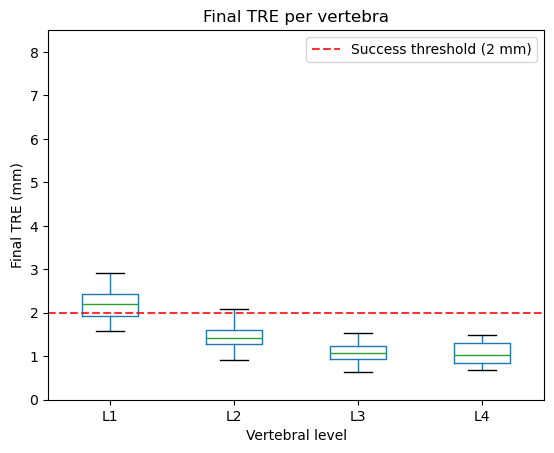

In [24]:
for exp_name, df in tables.items():
    plt.figure()

    box_df = df[[f"final_{v}" for v in ["L1","L2","L3","L4"]]]
    box_df.columns = ["L1", "L2", "L3", "L4"]

    box_df.boxplot(showfliers=False)

    plt.xlabel("Vertebral level")
    plt.ylabel("Final TRE (mm)")
    plt.title("Final TRE per vertebra")

    # identical y-limits
    plt.ylim(0, ymax)

    # 2 mm success threshold
    plt.axhline(
        2.0,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        color = "red",
        label="Success threshold (2 mm)"
    )

    plt.grid(False)
    plt.legend()
    plt.show()


## intial vs final plot

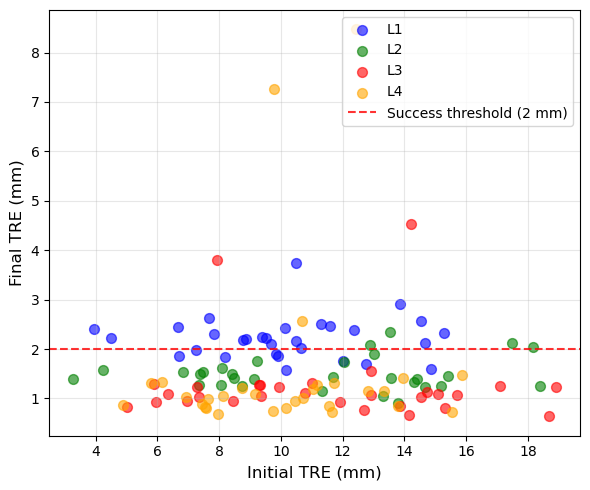

In [25]:
# Initial vs Final TRE scatter plot
for exp_name, df in tables.items():
    initial_tre = []
    final_tre = []
    vertebra_labels = []
    colors = []
    
    # Color map for vertebrae
    vertebra_colors = {'L1': 'blue', 'L2': 'green', 'L3': 'red', 'L4': 'orange'}
    
    # Collect all data points from the DataFrame
    for vertebra in ['L1', 'L2', 'L3', 'L4']:
        initial_tre.extend(df[f'init_{vertebra}'].values)
        final_tre.extend(df[f'final_{vertebra}'].values)
        vertebra_labels.extend([vertebra] * len(df))
        colors.extend([vertebra_colors[vertebra]] * len(df))
    
    # Create scatter plot
    plt.figure(figsize=(6, 5))
    for vertebra in ['L1', 'L2', 'L3', 'L4']:
        mask = np.array(vertebra_labels) == vertebra
        plt.scatter(
            np.array(initial_tre)[mask], 
            np.array(final_tre)[mask],
            c=vertebra_colors[vertebra],
            label=vertebra,
            alpha=0.6,
            s=50
        )
    
    
    # Add success threshold line
    plt.axhline(2.0, linestyle='--', linewidth=1.5, alpha=0.8, color='red', 
                label='Success threshold (2 mm)')
    
    plt.xlabel('Initial TRE (mm)', fontsize=12)
    plt.ylabel('Final TRE (mm)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()